# 0 - Basic Validation

This notebook validates core data quality assumptions before modeling, with emphasis on:
- numeric outliers (boxplots + IQR summary),
- target distributions (`Opportunity Amount USD` and `Opportunity Result`),
- process consistency checks (`Total Days...` + stage ratios),
- repeated records per `Opportunity Number`.


In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')


In [58]:
DATA_PATH = '../../data/raw/cars.xlsx'
df = pd.read_excel(DATA_PATH)

In [59]:
print('shape:', df.shape)
print('columns:', len(df.columns))
display(df.dtypes)
display(df.head(3))


shape: (78025, 19)
columns: 19


Opportunity Number                            int64
Supplies Group                                  str
Supplies Subgroup                               str
Region                                          str
Route To Market                                 str
Elapsed Days In Sales Stage                   int64
Opportunity Result                              str
Sales Stage Change Count                      int64
Total Days Identified Through Closing         int64
Total Days Identified Through Qualified       int64
Opportunity Amount USD                        int64
Client Size By Revenue (USD)                    str
Client Size By Employee Count                   str
Revenue From Client Past Two Years (USD)        str
Competitor Type                                 str
Ratio Days Identified To Total Days         float64
Ratio Days Validated To Total Days          float64
Ratio Days Qualified To Total Days          float64
Deal Size Category (USD)                        str
dtype: objec

,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD)
0,1641984,Car Accessories,Exterior Accessories,Northwest,Fields Sales,76,Won,13,104,101,0,More than 1M,More than 25K,0 (No business),Unknown,0.6964,0.1140,0.1542,10K or less
1,1658010,Car Accessories,Exterior Accessories,Pacific,Reseller,63,Loss,2,163,163,0,250K to 500K,More than 25K,0 (No business),Unknown,0.0000,1.0000,0.0000,10K or less
2,1674737,Performance & Non-auto,Motorcycle Parts,Pacific,Reseller,24,Won,7,82,82,7750,100K or less,1K or less,0 (No business),Unknown,1.0000,0.0000,0.0000,10K or less


In [60]:
df.describe(include='all')

,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD)
count,"78,025.0000",78025,78025,78025,78025,"78,025.0000",78025,"78,025.0000","78,025.0000","78,025.0000","78,025.0000",78025,78025,78025,68768,"78,025.0000","78,025.0000","78,025.0000",78025
unique,NaN,4,11,7,5,NaN,2,NaN,NaN,NaN,NaN,5,5,5,2,NaN,NaN,NaN,7
top,NaN,Car Accessories,Motorcycle Parts,Midwest,Fields Sales,NaN,Loss,NaN,NaN,NaN,NaN,100K or less,1K or less,0 (No business),Unknown,NaN,NaN,NaN,40K to 50K
freq,NaN,49810,15174,21020,37262,NaN,60398,NaN,NaN,NaN,NaN,59504,59348,69208,56724,NaN,NaN,NaN,18074
mean,"7,653,428.7343",NaN,NaN,NaN,NaN,43.5953,NaN,2.9557,16.7284,16.3143,"91,637.2607",NaN,NaN,NaN,NaN,0.2031,0.4883,0.1850,NaN
std,"1,054,847.7631",NaN,NaN,NaN,NaN,26.5856,NaN,1.4972,16.7296,16.5626,"133,161.0292",NaN,NaN,NaN,NaN,0.3650,0.4481,0.3403,NaN
min,"1,641,984.0000",NaN,NaN,NaN,NaN,0.0000,NaN,1.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN
25%,"6,900,423.0000",NaN,NaN,NaN,NaN,19.0000,NaN,2.0000,4.0000,4.0000,"15,000.0000",NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN
50%,"7,545,569.0000",NaN,NaN,NaN,NaN,43.0000,NaN,3.0000,12.0000,12.0000,"49,000.0000",NaN,NaN,NaN,NaN,0.0000,0.4480,0.0000,NaN
75%,"8,228,329.0000",NaN,NaN,NaN,NaN,65.0000,NaN,3.0000,24.0000,24.0000,"105,099.0000",NaN,NaN,NaN,NaN,0.1972,1.0000,0.1886,NaN


## 1) Target distributions


In [61]:
target_col_amount = 'Opportunity Amount USD'
target_col_result = 'Opportunity Result'

result_dist = (
    df[target_col_result]
    .value_counts(dropna=False)
    .rename('count')
    .to_frame()
)
result_dist['pct'] = (result_dist['count'] / len(df) * 100).round(2)

amount_summary = df[target_col_amount].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('value')

print('Opportunity Result distribution:')
display(result_dist)
print('Opportunity Amount USD summary:')
display(amount_summary)


Opportunity Result distribution:


,count,pct
Opportunity Result,,
Loss,60398,77.4100
Won,17627,22.5900


Opportunity Amount USD summary:


,value
count,"78,025.0000"
mean,"91,637.2607"
std,"133,161.0292"
min,0.0000
1%,0.0000
5%,"1,192.8000"
25%,"15,000.0000"
50%,"49,000.0000"
75%,"105,099.0000"
95%,"350,000.0000"


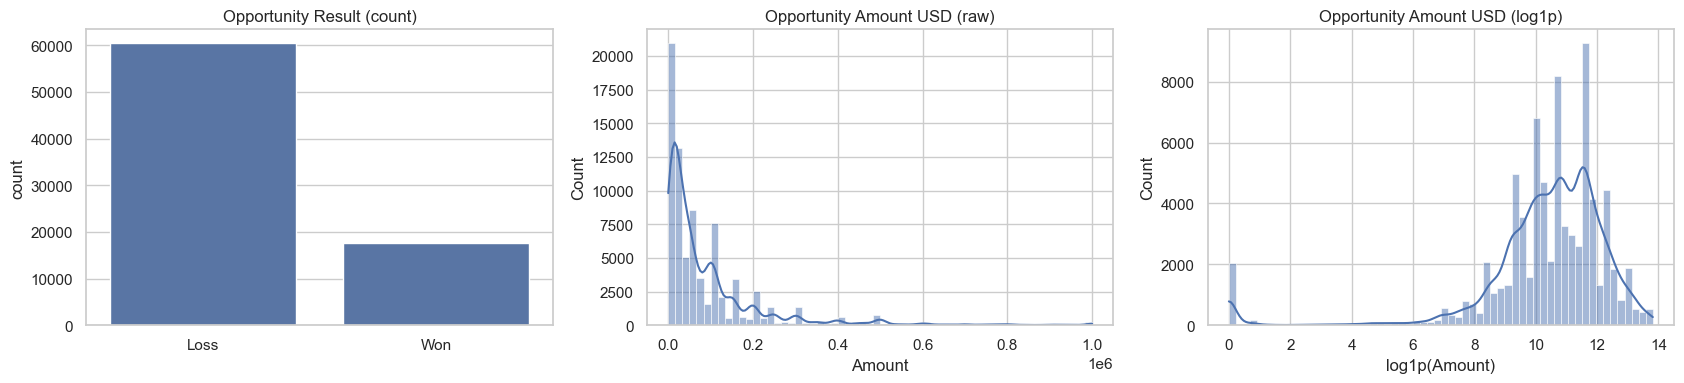

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

order = df[target_col_result].value_counts().index
sns.countplot(data=df, x=target_col_result, order=order, ax=axes[0])
axes[0].set_title('Opportunity Result (count)')
axes[0].set_xlabel('')

sns.histplot(df[target_col_amount], bins=60, kde=True, ax=axes[1])
axes[1].set_title('Opportunity Amount USD (raw)')
axes[1].set_xlabel('Amount')

sns.histplot(np.log1p(df[target_col_amount]), bins=60, kde=True, ax=axes[2])
axes[2].set_title('Opportunity Amount USD (log1p)')
axes[2].set_xlabel('log1p(Amount)')

plt.tight_layout()


## 2) Numeric outliers (IQR + boxplots)


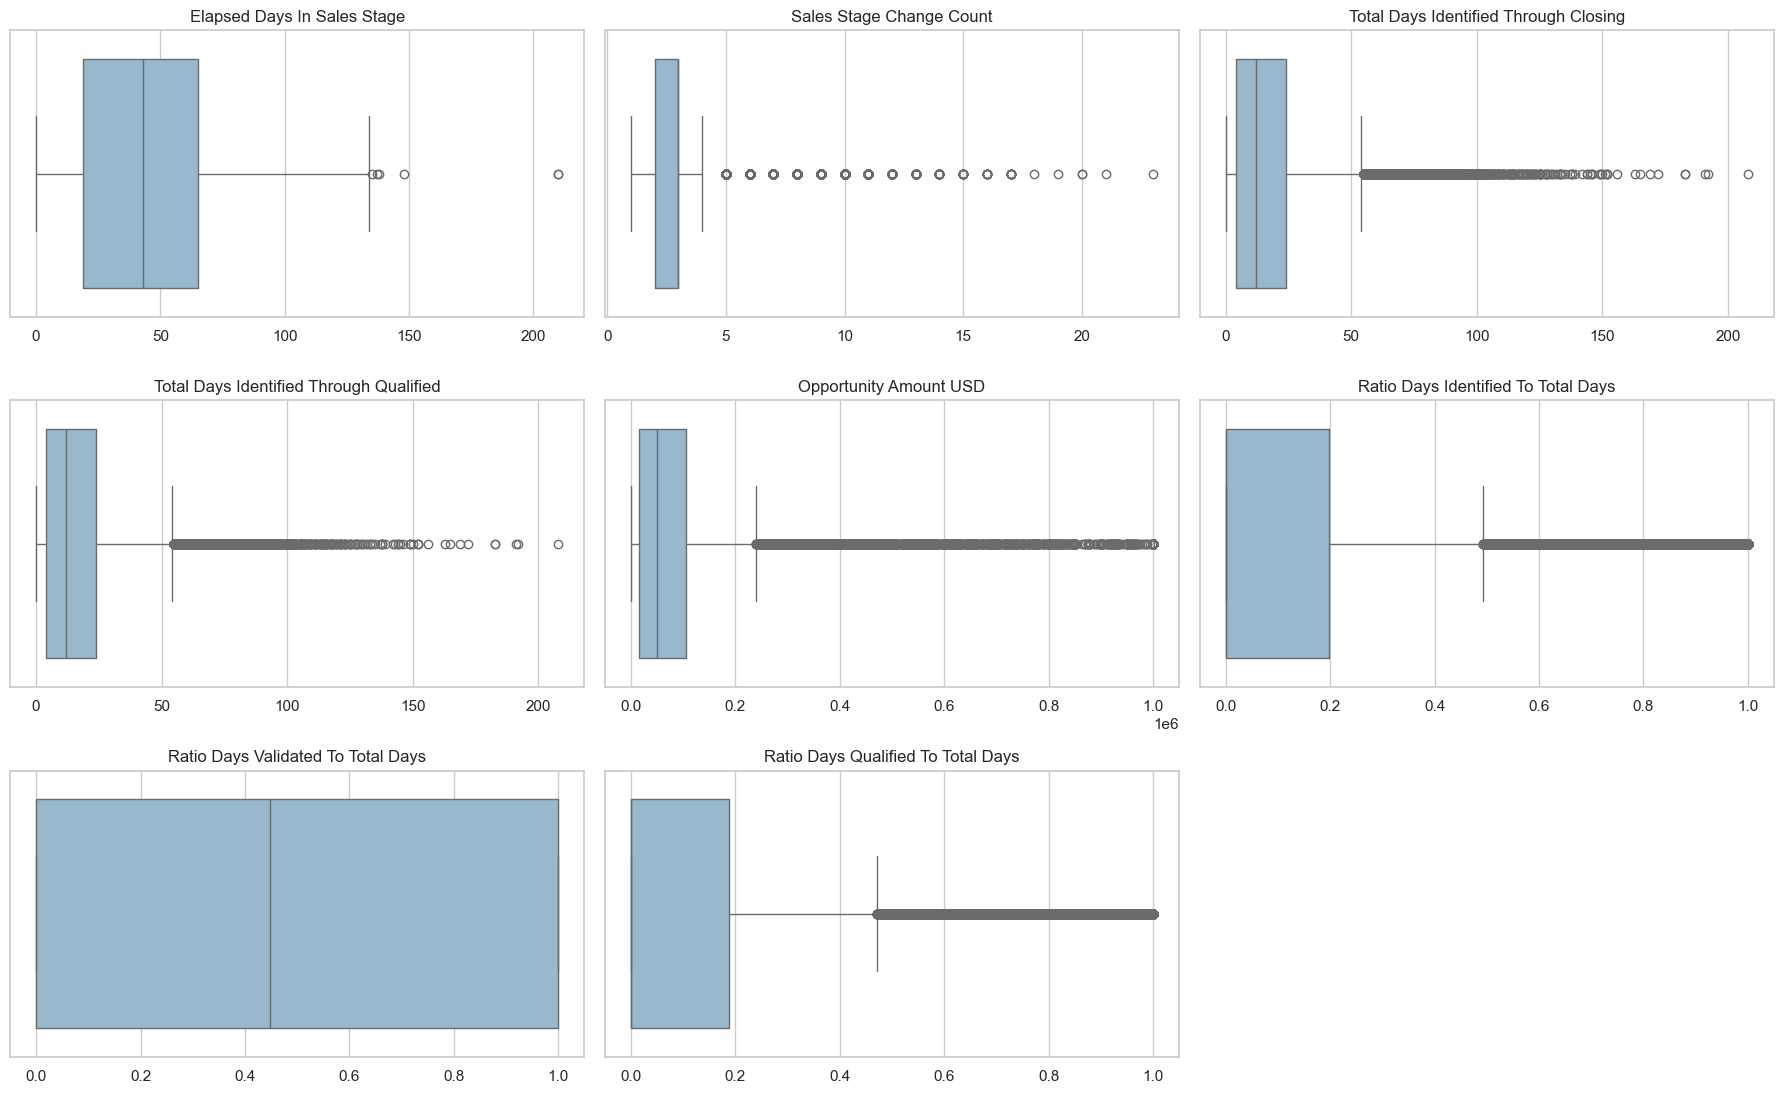

In [63]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove("Opportunity Number")  # Exclude target variable from numeric columns

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.7 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#8fbad6')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()


In [64]:
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_count = ((df[numeric_cols] < lower) | (df[numeric_cols] > upper)).sum().rename('outlier_count')
outlier_pct = (outlier_count / len(df) * 100).rename('outlier_pct')

outlier_table = pd.concat([
    q1.rename('q1'),
    q3.rename('q3'),
    iqr.rename('iqr'),
    lower.rename('lower_bound'),
    upper.rename('upper_bound'),
    outlier_count,
    outlier_pct.round(2)
], axis=1).sort_values('outlier_pct', ascending=False)

outlier_table


,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
Ratio Days Identified To Total Days,0.0000,0.1972,0.1972,-0.2958,0.4931,14983,19.2000
Ratio Days Qualified To Total Days,0.0000,0.1886,0.1886,-0.2828,0.4714,14948,19.1600
Sales Stage Change Count,2.0000,3.0000,1.0000,0.5000,4.5000,9340,11.9700
Opportunity Amount USD,"15,000.0000","105,099.0000","90,099.0000","-120,148.5000","240,247.5000",7273,9.3200
Total Days Identified Through Closing,4.0000,24.0000,20.0000,-26.0000,54.0000,2706,3.4700
Total Days Identified Through Qualified,4.0000,24.0000,20.0000,-26.0000,54.0000,2566,3.2900
Elapsed Days In Sales Stage,19.0000,65.0000,46.0000,-50.0000,134.0000,6,0.0100
Ratio Days Validated To Total Days,0.0000,1.0000,1.0000,-1.5000,2.5000,0,0.0000


## 3) Process consistency checks


In [65]:
total_days_col = 'Total Days Identified Through Closing'
total_siebel_col = 'Total Days Identified Through Qualified'
ratio_cols = [
    'Ratio Days Identified To Total Days',
    'Ratio Days Validated To Total Days',
    'Ratio Days Qualified To Total Days'
]

### 3.1) Total Days consistency

Assumption: `Total Days in Sales Process` should be > 0 for all records, as it represents the duration of the sales process.


In [68]:
df["total_days_zero"] = df[total_days_col] == 0
df["Opportunity Result Bool"] = df["Opportunity Result"] == 'Won'

In [69]:
df.groupby("total_days_zero")[["Opportunity Result Bool", "Opportunity Amount USD"]].agg(['count', 'mean'])

Opportunity Result Bool        Opportunity Amount USD  \
                                  count   mean                  count   
total_days_zero                                                         
False                             69736 0.2035                  69736   
True                               8289 0.4144                   8289   

                             
                       mean  
total_days_zero              
False           93,852.3172  
True            73,001.8190

Apparently there are some records with `Total Days in Sales Process` = 0, and weirdly they have a higher win rate than the rest of the data. This is a red flag that these records might be erroneous or they represent after-the-fact records that are useless for modeling. We should investigate further before modeling.

## 3.2 Other consistency checks (stage ratios)

Assumption: Total days and ratios of days in each stage should be consistent with the expected sales process. For example, if `Total Days in Sales Process` is 10, we would expect that the sum of days in each stage equals 10, and that the ratios of days in each stage are reasonable (e.g., not all days spent in one stage).

In [41]:
check = df[[total_days_col, total_siebel_col] + ratio_cols].copy()
check['ratio_sum'] = check[ratio_cols].sum(axis=1)
check['implied_days_from_ratios'] = check['ratio_sum'] * check[total_days_col]
check['ratio_sum_abs_error'] = (check['ratio_sum'] - 1.0).abs()
check['siebel_le_total_days'] = check[total_siebel_col] <= check[total_days_col]

consistency_summary = pd.DataFrame({
    'metric': [
        'rows_total',
        'rows_total_days_negative',
        'rows_total_siebel_negative',
        'rows_total_siebel_gt_total_days',
        'rows_ratio_sum_not_close_to_1 (tol=0.01)',
        'rows_any_ratio_outside_0_1',
        'rows_ratio_days_implied_diff_gt_1day'
    ],
    'count': [
        len(check),
        int((check[total_days_col] < 0).sum()),
        int((check[total_siebel_col] < 0).sum()),
        int((~check['siebel_le_total_days']).sum()),
        int((check['ratio_sum_abs_error'] > 0.01).sum()),
        int(((check[ratio_cols] < 0) | (check[ratio_cols] > 1)).any(axis=1).sum()),
        int(((check['implied_days_from_ratios'] - check[total_days_col]).abs() > 1).sum())
    ]
})

consistency_summary['pct'] = (consistency_summary['count'] / len(check) * 100).round(2)

consistency_summary


,metric,count,pct
0,rows_total,78025,100.0000
1,rows_total_days_negative,0,0.0000
2,rows_total_siebel_negative,0,0.0000
3,rows_total_siebel_gt_total_days,0,0.0000
4,rows_ratio_sum_not_close_to_1 (tol=0.01),12921,16.5600
5,rows_any_ratio_outside_0_1,0,0.0000
6,rows_ratio_days_implied_diff_gt_1day,4127,5.2900


<Axes: >

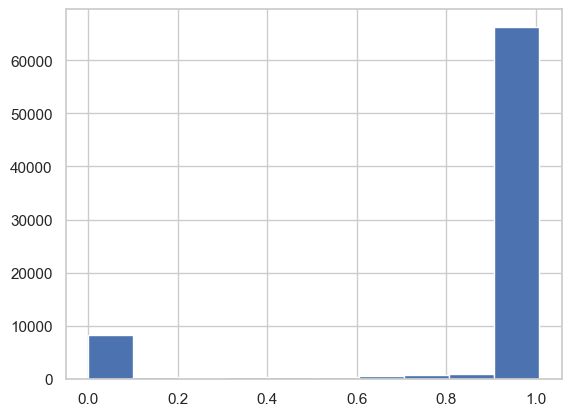

In [42]:
check['ratio_sum'].hist()

In [43]:
worst_ratio_rows = (
    check.assign(opportunity_number=df['Opportunity Number'])
    .sort_values('ratio_sum_abs_error', ascending=False)
    .head(15)
)

print('Top 15 rows by ratio-sum error:')
display(worst_ratio_rows[['opportunity_number', total_days_col, total_siebel_col] + ratio_cols + ['ratio_sum', 'ratio_sum_abs_error']])


Top 15 rows by ratio-sum error:


,opportunity_number,Total Days Identified Through Closing,Total Days Identified Through Qualified,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,ratio_sum,ratio_sum_abs_error
78024,10094255,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40772,9469192,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40748,9468343,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40747,9468330,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40745,9467753,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40744,9467649,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40742,9467239,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40730,9466724,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40724,9466450,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40713,9466078,0,0,0.0000,0.0000,0.0000,0.0000,1.0000


### 3.3) Early-days focus (0-1 days) for top day-related issues\n

In [44]:
top_day_issues = (
    check.assign(
        opportunity_number=df['Opportunity Number'],
        opportunity_result=df['Opportunity Result']
    )
    .sort_values('ratio_sum_abs_error', ascending=False)
    .head(15)
)

print('Top 15 day-consistency issues (sorted by ratio-sum error):')
display(
    top_day_issues[[
        'opportunity_number',
        'opportunity_result',
        total_days_col,
        total_siebel_col,
        'ratio_sum',
        'ratio_sum_abs_error'
    ]]
)

early_issue_summary = pd.DataFrame({
    'metric': [
        'top15_count',
        'top15_with_total_days_0_1',
        'top15_pct_total_days_0_1',
        'full_dataset_with_total_days_0_1',
        'full_dataset_pct_total_days_0_1'
    ],
    'value': [
        len(top_day_issues),
        int((top_day_issues[total_days_col] <= 1).sum()),
        round((top_day_issues[total_days_col] <= 1).mean() * 100, 2),
        int((check[total_days_col] <= 1).sum()),
        round((check[total_days_col] <= 1).mean() * 100, 2)
    ]
})

print('0-1 day concentration summary:')
display(early_issue_summary)


Top 15 day-consistency issues (sorted by ratio-sum error):


,opportunity_number,opportunity_result,Total Days Identified Through Closing,Total Days Identified Through Qualified,ratio_sum,ratio_sum_abs_error
78024,10094255,Loss,0,0,0.0000,1.0000
40772,9469192,Won,0,0,0.0000,1.0000
40748,9468343,Loss,0,0,0.0000,1.0000
40747,9468330,Loss,0,0,0.0000,1.0000
40745,9467753,Loss,0,0,0.0000,1.0000
40744,9467649,Loss,0,0,0.0000,1.0000
40742,9467239,Won,0,0,0.0000,1.0000
40730,9466724,Won,0,0,0.0000,1.0000
40724,9466450,Won,0,0,0.0000,1.0000
40713,9466078,Loss,0,0,0.0000,1.0000


0-1 day concentration summary:


,metric,value
0,top15_count,15.0000
1,top15_with_total_days_0_1,15.0000
2,top15_pct_total_days_0_1,100.0000
3,full_dataset_with_total_days_0_1,"11,618.0000"
4,full_dataset_pct_total_days_0_1,14.8900


Win/Loss probability by total-days bin (first bin = 0-1):


,days_bin,opportunities,win_probability
0,0-1,11618,0.4194
1,2-3,6100,0.4621
2,4-7,10487,0.3358
3,8-14,14817,0.2086
4,15-30,21951,0.1091
5,31-60,11211,0.0712
6,61-90,1518,0.0672
7,91-180,318,0.0849
8,181-365,5,0.2000
9,366+,0,NaN


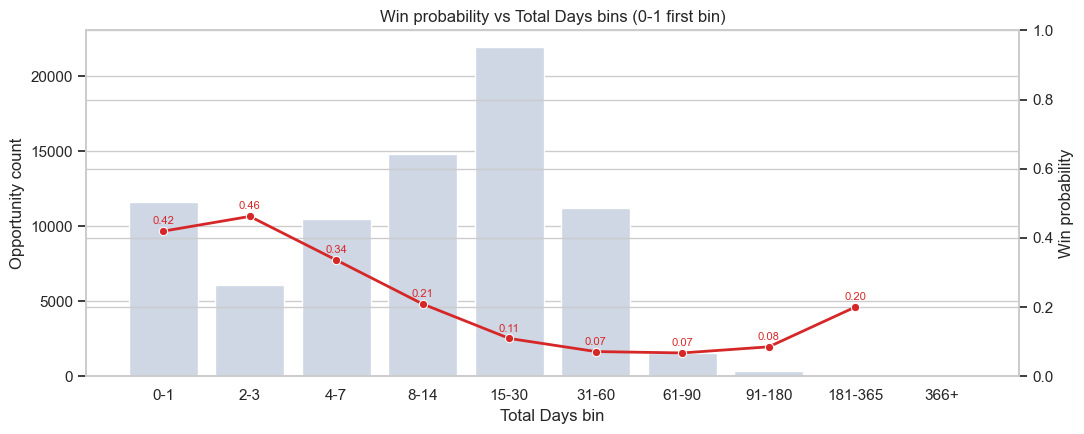

In [45]:
bin_edges = [-0.1, 1, 3, 7, 14, 30, 60, 90, 180, 365, np.inf]
bin_labels = ['0-1', '2-3', '4-7', '8-14', '15-30', '31-60', '61-90', '91-180', '181-365', '366+']

tmp = df[[total_days_col, 'Opportunity Result']].copy()
tmp['days_bin'] = pd.cut(tmp[total_days_col], bins=bin_edges, labels=bin_labels, include_lowest=True)
tmp['is_win'] = tmp['Opportunity Result'].eq('Won').astype(int)

winloss_by_bin = (
    tmp.groupby('days_bin', observed=False)
    .agg(
        opportunities=('is_win', 'size'),
        win_probability=('is_win', 'mean')
    )
    .reset_index()
)
winloss_by_bin['win_probability'] = winloss_by_bin['win_probability'].round(4)

print('Win/Loss probability by total-days bin (first bin = 0-1):')
display(winloss_by_bin)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=winloss_by_bin, x='days_bin', y='opportunities', color='#cbd5e8', ax=ax1)
ax1.set_ylabel('Opportunity count')
ax1.set_xlabel('Total Days bin')
ax1.set_title('Win probability vs Total Days bins (0-1 first bin)')

ax2 = ax1.twinx()
sns.lineplot(data=winloss_by_bin, x='days_bin', y='win_probability', marker='o', color='#d62728', linewidth=2, ax=ax2)
ax2.set_ylabel('Win probability')
ax2.set_ylim(0, 1)

for i, r in winloss_by_bin.iterrows():
    ax2.text(i, r['win_probability'] + 0.02, f"{r['win_probability']:.2f}", ha='center', fontsize=8, color='#d62728')

plt.tight_layout()


There are two modalities in the `Total Days in Sales Process` distribution: one at 0-1 (maybe up to 3) days and another around up to 90 days. The 0-day modality is particularly concerning, as it suggests that there are many records where the sales process duration is recorded as zero, which is likely incorrect. This could indicate data entry errors or a misunderstanding of what the `Total Days in Sales Process` field represents.

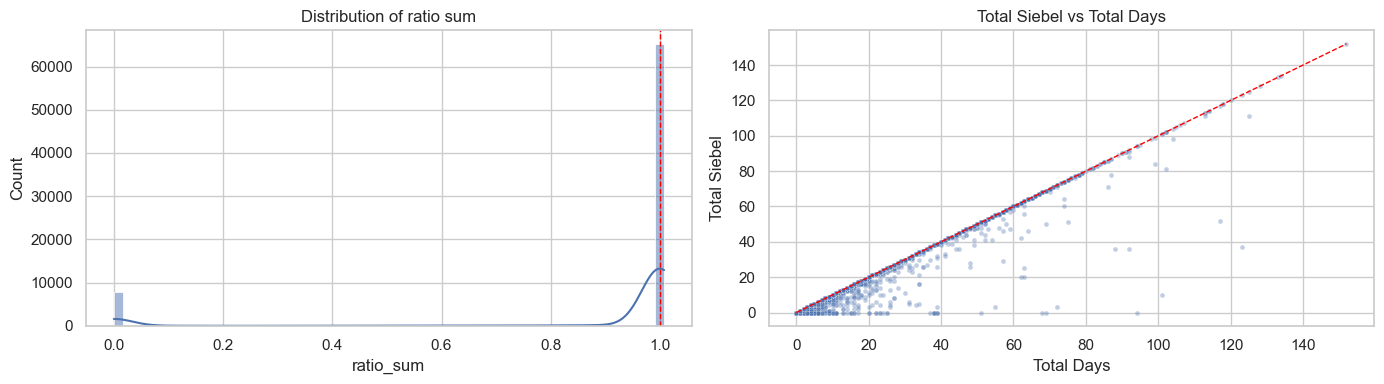

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(check['ratio_sum'], bins=60, kde=True, ax=axes[0])
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of ratio sum')
axes[0].set_xlabel('ratio_sum')

sample = check[[total_days_col, total_siebel_col]].sample(min(10000, len(check)), random_state=42)
max_lim = float(max(sample[total_days_col].max(), sample[total_siebel_col].max()))

sns.scatterplot(data=sample, x=total_days_col, y=total_siebel_col, s=12, alpha=0.35, ax=axes[1])
axes[1].plot([0, max_lim], [0, max_lim], color='red', linestyle='--', linewidth=1)
axes[1].set_title('Total Siebel vs Total Days')
axes[1].set_xlabel('Total Days')
axes[1].set_ylabel('Total Siebel')

plt.tight_layout()


## 4) ID analysis (potential repeated `Opportunity Number` records)


In [47]:
id_col = 'Opportunity Number'

id_counts = df[id_col].value_counts(dropna=False)
rows_with_repeated_id = int(id_counts[id_counts > 1].sum())
ids_with_repeats = int((id_counts > 1).sum())

dup_summary = pd.DataFrame({
    'metric': [
        'rows_total',
        'unique_ids',
        'ids_with_more_than_one_record',
        'rows_belonging_to_repeated_ids',
        'max_rows_for_single_id'
    ],
    'value': [
        len(df),
        int(df[id_col].nunique(dropna=False)),
        ids_with_repeats,
        rows_with_repeated_id,
        int(id_counts.max())
    ]
})

dup_summary


,metric,value
0,rows_total,78025
1,unique_ids,77829
2,ids_with_more_than_one_record,183
3,rows_belonging_to_repeated_ids,379
4,max_rows_for_single_id,4


In [48]:
duplicate_rows = df[df[id_col].duplicated(keep=False)].copy()
non_id_cols = [c for c in df.columns if c != id_col]

id_state_summary = []
for oid, grp in duplicate_rows.groupby(id_col, sort=False):
    distinct_states = grp[non_id_cols].drop_duplicates().shape[0]
    id_state_summary.append({
        id_col: int(oid),
        'rows_for_id': int(len(grp)),
        'distinct_states_excl_id': int(distinct_states),
        'is_exact_repeat_only': bool(distinct_states == 1)
    })

id_state_summary = pd.DataFrame(id_state_summary)

print('Duplicate-ID detail sample:')
display(id_state_summary.sort_values(['rows_for_id', 'distinct_states_excl_id'], ascending=False).head(20))


Duplicate-ID detail sample:


,Opportunity Number,rows_for_id,distinct_states_excl_id,is_exact_repeat_only
42,7281765,4,3,False
181,9782603,4,2,False
79,8093335,4,1,True
32,6835459,3,3,False
107,4787647,3,3,False
146,7239544,3,3,False
50,7463337,3,2,False
170,8445253,3,2,False
25,6704540,3,1,True
82,8133081,3,1,True


This shows to things about the data:
- 1. The dataset is mostly made of single slice records per `Opportunity Number`, which means that each record represents a unique sales opportunity. This means the dataset is partially useful for modeling, since it will be biased (hopefully if every opportunity is represented as its end) towards the final stages of the sales process, but it is not completely useless.
- 2. There are some repeated `Opportunity Number` records, which could indicate that there are multiple records for the same sales opportunity. This could be due to data entry errors, or it could be that the dataset includes multiple records for the same opportunity at different stages of the sales process. This is a red flag that we need to investigate further before modeling, as it could lead to data leakage if we have multiple records for the same opportunity in both the training and test sets.

## 5) Final row-level problem tagging

This section creates a final per-row quality view with:
- `problem_tags`: list of all detected issues per row,
- `problem_count`: number of issues in that list,
- `partial_repeat_is_latest_id_appearance`: marker for the latest row among partial duplicates of the same ID.

In [70]:
df_tagged = df.copy()
df_tagged['row_position'] = np.arange(len(df_tagged))

# Outlier thresholds from previously computed IQR bounds
amount_lower = lower[target_col_amount]
amount_upper = upper[target_col_amount]
days_lower = lower[total_days_col]
days_upper = upper[total_days_col]

# Ratio-related issues
ratio_sum_not_close = check['ratio_sum_abs_error'] > 0.01
ratio_outside_0_1 = ((check[ratio_cols] < 0) | (check[ratio_cols] > 1)).any(axis=1)
ratio_implied_days_mismatch = (check['implied_days_from_ratios'] - check[total_days_col]).abs() > 1
ratio_problem = ratio_sum_not_close | ratio_outside_0_1 | ratio_implied_days_mismatch

# Duplicate logic
exact_row_duplicate = df.duplicated(keep=False)
id_repeated = df[id_col].duplicated(keep=False)

non_id_cols = [c for c in df.columns if c != id_col]
distinct_states_per_id = (
    df.groupby(id_col, sort=False)[non_id_cols]
    .apply(lambda g: g.drop_duplicates().shape[0])
)
partial_repeat_by_id = id_repeated & df[id_col].map(distinct_states_per_id).gt(1)

latest_id_appearance = id_repeated & df.groupby(id_col, sort=False).cumcount(ascending=False).eq(0)
partial_repeat_is_latest = partial_repeat_by_id & latest_id_appearance

# Row-level flags requested
df_tagged['flag_0_days'] = df[total_days_col].eq(0)
df_tagged['flag_ratio_problem'] = ratio_problem
df_tagged['flag_zero_opportunity_amount'] = df[target_col_amount].eq(0)
df_tagged['flag_outlier_opportunity_amount'] = (df[target_col_amount] < amount_lower) | (df[target_col_amount] > amount_upper)
df_tagged['flag_outlier_total_days'] = (df[total_days_col] < days_lower) | (df[total_days_col] > days_upper)
df_tagged['flag_totally_repeated_row'] = exact_row_duplicate
df_tagged['flag_partially_repeated_row'] = partial_repeat_by_id
df_tagged['partial_repeat_is_latest_id_appearance'] = partial_repeat_is_latest

problem_label_map = {
    'flag_0_days': '0_days',
    'flag_ratio_problem': 'ratio_problem',
    'flag_zero_opportunity_amount': 'zero_opportunity_amount',
    'flag_outlier_opportunity_amount': 'outlier_opportunity_amount',
    'flag_outlier_total_days': 'outlier_total_days',
    'flag_totally_repeated_row': 'totally_repeated_row',
    'flag_partially_repeated_row': 'partially_repeated_row'
}

flag_cols = list(problem_label_map.keys())
df_tagged['problem_tags'] = df_tagged[flag_cols].apply(
    lambda r: [problem_label_map[c] for c in flag_cols if bool(r[c])],
    axis=1
)
df_tagged['problem_count'] = df_tagged[flag_cols].sum(axis=1).astype(int)

problem_summary = pd.DataFrame({
    'problem': list(problem_label_map.values()),
    'rows_flagged': [int(df_tagged[c].sum()) for c in flag_cols]
})
problem_summary['pct_rows'] = (problem_summary['rows_flagged'] / len(df_tagged) * 100).round(2)
problem_summary = problem_summary.sort_values(['rows_flagged', 'problem'], ascending=[False, True])

print('Problem summary (requested checks):')
display(problem_summary)

print('Rows with highest number of issues:')
display_cols = [
    id_col,
    total_days_col,
    target_col_amount,
    'problem_tags',
    'problem_count',
    'partial_repeat_is_latest_id_appearance'
]
display(
    df_tagged
    .sort_values(['problem_count', id_col], ascending=[False, True])
    [display_cols]
    .head(25)
)

print('Final row-level analysis dataset is available in: df_tagged')



Problem summary (requested checks):


,problem,rows_flagged,pct_rows
1,ratio_problem,12921,16.5600
0,0_days,8289,10.6200
3,outlier_opportunity_amount,7273,9.3200
4,outlier_total_days,2706,3.4700
2,zero_opportunity_amount,2047,2.6200
6,partially_repeated_row,283,0.3600
5,totally_repeated_row,105,0.1300


Rows with highest number of issues:


,Opportunity Number,Total Days Identified Through Closing,Opportunity Amount USD,problem_tags,problem_count,partial_repeat_is_latest_id_appearance
45714,1724032,94,469000,"[ratio_problem, outlier_opportunity_amount, ou...",4,False
45715,1724032,94,469000,"[ratio_problem, outlier_opportunity_amount, ou...",4,False
4146,6384089,0,0,"[0_days, ratio_problem, zero_opportunity_amoun...",4,False
4147,6384089,0,0,"[0_days, ratio_problem, zero_opportunity_amoun...",4,True
52739,6824479,0,0,"[0_days, ratio_problem, zero_opportunity_amoun...",4,False
52740,6824479,0,0,"[0_days, ratio_problem, zero_opportunity_amoun...",4,False
52788,6827983,0,0,"[0_days, ratio_problem, zero_opportunity_amoun...",4,False
52789,6827983,0,0,"[0_days, ratio_problem, zero_opportunity_amoun...",4,False
10376,6831434,0,240963,"[0_days, ratio_problem, outlier_opportunity_am...",4,True
28699,7860475,0,243072,"[0_days, ratio_problem, outlier_opportunity_am...",4,False


Final row-level analysis dataset is available in: df_tagged


In [71]:
df_tagged["problem_count"].value_counts(normalize=True).sort_index().mul(100).round(2)

problem_count
0   69.4800
1   19.3700
2    9.7300
3    1.4000
4    0.0100
Name: proportion, dtype: float64

<Axes: xlabel='problem_count'>

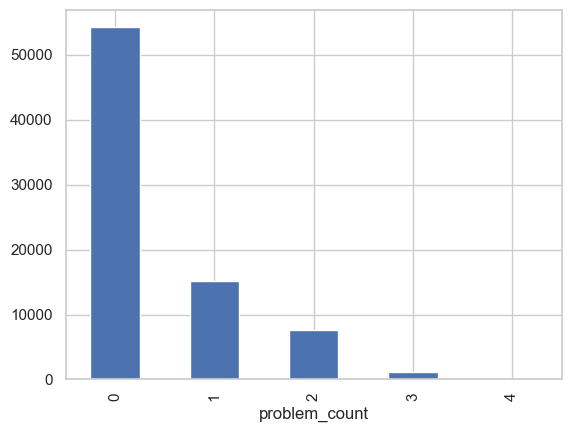

In [72]:
df_tagged["problem_count"].value_counts().plot.bar()

## 6) Quick conclusions

- Target imbalance exists in `Opportunity Result` and amount has strong skew (raw vs log plots).
- Numeric outlier concentrations are visible in selected variables from IQR + boxplots.
- Process constraints are checked explicitly (`ratio_sum ~= 1`, `Total Siebel <= Total Days`).
- Duplicate `Opportunity Number` records are measured and split into exact repeats vs state-change records.
- Most severe day-consistency issues are concentrated in very short cycles (0-1 days), so this segment is analyzed first.\n- Win/Loss probability is profiled against ordered total-day bins with `0-1` as the first bucket.\n


In [ ]:
from pathlib import Path

# Select which problems to remove (leave commented to keep all for now)
problems_to_remove = [
    '0_days',
    'ratio_problem',
    'zero_opportunity_amount',
    'outlier_opportunity_amount',
    'outlier_total_days',
    'totally_repeated_row',
    'partially_repeated_row',
]

working = df_tagged.copy()

if problems_to_remove:
    selected = set(problems_to_remove)
    working = working[~working['problem_tags'].apply(lambda tags: any(t in selected for t in tags))].copy()

# Always deduplicate by ID, keeping the most recent appearance in dataset order
working = (
    working
    .sort_values('row_position')
    .drop_duplicates(subset=[id_col], keep='last')
)

# Export only original columns to preserve source schema
export_df = working[df.columns.tolist()].copy()

output_path = Path('../../data/intermediate/cleaned_data.xlsx')
output_path.parent.mkdir(parents=True, exist_ok=True)
export_df.to_excel(output_path, index=False)

print(f'Rows before filtering: {len(df_tagged):,}')
print(f'Rows after problem filtering: {len(working):,}')
print(f'Rows exported after latest-per-ID dedup: {len(export_df):,}')
print(f'File written to: {output_path}')

